# Custom Mapping Function: Drift Angle Modulation Using Utility Theory

This tutorial demonstrates how to define a **custom mapping function** that maps **trial-wise stimuli** to **trial-wise model parameters**.  
The example uses a pricing paradigm in which, on each trial, a participant evaluates a lottery that pays an outcome `x` with probability `p` (otherwise $0$) and reports a **willingness-to-pay (WTP)** on a bounded scale from $\$ 0$ to $\$ 20$.

To model this scenario, we use a **Projected Spherical Diffusion Model (PSDM)** and combine it with a simple **utility function** so that the **drift direction** (angle) varies by trial as a function of the subjective utility of the presented lottery.

## 1. Import required packages

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from jeam.Models.Spherical import ProjectedSphericalDiffusionModel as PSDM

## 2. Create a projected spherical diffusion model

This model is useful for **bounded response scales**, which often are employed in the estimation or valuation tasks. 

In [2]:
model = PSDM(threshold_dynamic='fixed')

## 3. Generate trial-wise lotteries

In each trial, a lottery with probability of winning $p \in [0.1, 0.9]$ and outcome $x \in [10, 20]$ is presented.

In [3]:
n_sample = 500
probability = np.random.uniform(0.1, 0.9, n_sample)
outcome = np.random.uniform(10, 20, n_sample)

## 4. Define the custom mapping and simulate data

### Utility model

We define subjective utility as:

$$u = p \cdot x^{\alpha},$$

where $\alpha$ is a utility power parameter.

### Mapping utility to drift angle

We map utility to a drift angle \(\theta_{\mu}\) over the response range:

$$
\theta_{\mu} = \frac{u}{\text{max response range}} \times \pi
= \frac{u}{20} \times \pi.
$$

This mapping function is introduced by [Kvam & Busemeyer (2020)](https://doi.org/10.1037/rev0000215)

### Drift vector (trial-wise)

Given a drift magnitude $\|\mu\|$, the trial-wise drift vectors are:

$$
\mu = \|\mu\| \times [\cos(\theta_{\mu}),\ \sin(\theta_{\mu})].
$$

### Simulate

In [4]:
# Ground-truth parameters
threshold = 3.0
utility_power = 0.5
drift_magnitude = 2.0
ndt = 0.25
max_response_range = 20.0

# Trial-wise subjective utility
subjective_utility = probability * outcome**utility_power

# Custom mapping: utility -> drift angle
drift_angles = subjective_utility / max_response_range * np.pi

# Trial-wise drift vectors
drift_vectors = drift_magnitude * np.c_[np.cos(drift_angles), 
                                        np.sin(drift_angles)]

# Simulate responses and RTs
sim_data = model.simulate(
    drift_vectors,
    ndt,
    threshold=threshold,
    n_sample=n_sample,
)

sim_data.head()

,rt,response
0,1.952,0.523037
1,1.172,0.163200
2,0.888,0.138872
3,0.735,1.507983
4,0.919,0.456168



The simulated dataset contains:
- `rt`: response times
- `response`: model responses on the model scale (radians). 

**Note:** For WTP on $[0, 20]$, you can convert via:  $\text{WTP} = \text{response}/\pi \times 20$.

## 5. Visualize simulated data

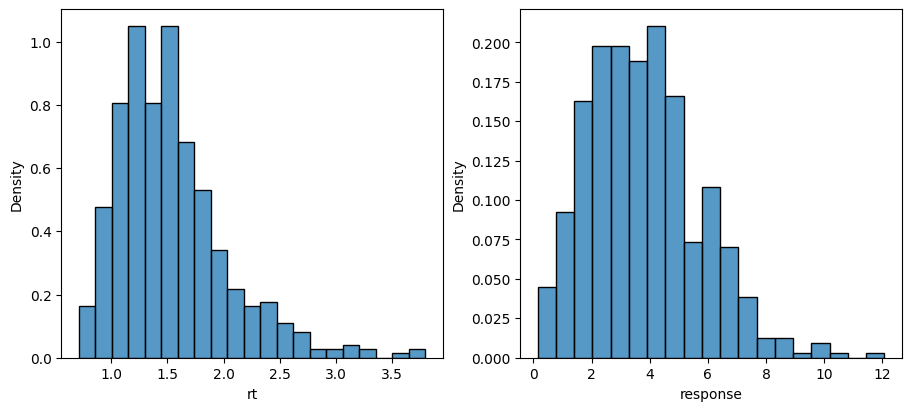

In [5]:
plt.figure(figsize=(9, 4), layout='constrained')
plt.subplot(121)
sns.histplot(sim_data['rt'], stat='density');

plt.subplot(122)
sns.histplot(sim_data['response']/np.pi * 20, stat='density');

## 6. Define the likelihood function

To estimate parameters, we define a negative log-likelihood.  
Critically, the **custom mapping** (probabilities and outcomes → drift angles → drift vectors) is recomputed inside the likelihood function.

In [6]:
def negative_log_likelihood(params, rt, theta, probability, outcome, model):
    threshold = params[0]
    ndt = params[1]
    drift_magnitude = params[2]
    utility_power = params[3]

    # Trial-wise utility
    subjective_utility = probability * outcome**utility_power

    # Custom mapping: utility -> drift angle (bounded scale [0, 20])
    drift_angles = subjective_utility / 20.0 * np.pi

    # Trial-wise drift vectors
    drift_vectors = drift_magnitude * np.c_[np.cos(drift_angles), 
                                            np.sin(drift_angles)]

    # Joint log-likelihood over RT and response
    logpdf = model.joint_lpdf(rt, theta, drift_vectors, ndt, threshold)
    return -np.sum(logpdf)

## 7. Estimate parameters using differential evolution

In [7]:
bounds = [
    (0.05, 5.0),  # threshold
    (0.0, 2.0),   # non-decision time
    (0.0, 5.0),   # drift magnitude
    (0.0, 1.0),   # utility power
]

param_names = ["threshold", "ndt", "drift_magnitude", "utility_power"]

result = differential_evolution(
    negative_log_likelihood,
    bounds=bounds,
    args=(
        sim_data["rt"].values,
        sim_data["response"].values,
        probability,
        outcome,
        model,
    ),
)

## 8. Inspect recovered parameters

In [8]:
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.3f}")

threshold: 3.051
ndt: 0.298
drift_magnitude: 2.078
utility_power: 0.515


If the model is identifiable for this configuration and the optimizer converges well, the recovered parameters should be close to the simulation values used above.


## Notes

- Custom mapping functions enable flexible model specification for stimulus dependent modulation of the models parameters.
- You can replace the utility model with any other mapping function, e.g. prospect theory, reference dependence, or regression-style mappings.
- The same pattern extends naturally to other CRDDM models and other parameters of the models.
- A parameter recovery study based on the task design and mapping function is required to ensure that the parameters are identifiable.

## Reference

- Kvam, P. D., & Busemeyer, J. R. (2020). A distributional and dynamic theory of pricing and preference. *Psychological Review*, 127(6), 1053–1078. [https://doi.org/10.1037/rev0000215](https://doi.org/10.1037/rev0000215)